In [44]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output

In [59]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

print(device)

mps


We’ll try to see whether a fully connected neural network can learn the sine function.

# Sin(x)

In [35]:
x = np.linspace(-5 * np.pi, 5 * np.pi, 10000)
y = np.sin(x)


x_tensor = torch.from_numpy(x).unsqueeze(dim = 1)
y_tensor = torch.from_numpy(y).unsqueeze(dim = 1)

print(f'dtype: {x_tensor.dtype}')
print(f'dtype: {y_tensor.dtype}')

x_tensor = x_tensor.float()
y_tensor = y_tensor.float()

print(f'dim of X: {x_tensor.shape} and dtype: {x_tensor.dtype}')
print(f'dim of Y: {y_tensor.shape} and dtype: {y_tensor.dtype}')

dtype: torch.float64
dtype: torch.float64
dim of X: torch.Size([10000, 1]) and dtype: torch.float32
dim of Y: torch.Size([10000, 1]) and dtype: torch.float32


NOTE: NumPy → PyTorch dtype mismatch
-------------------------------------
np.linspace / np.sin / most NumPy ops default to float64 ("Double" in torch).
nn.Linear and most PyTorch layers default to float32 ("Float").

torch.from_numpy() preserves the source dtype — it does NOT auto-cast.
So torch.from_numpy(some_float64_array) -> torch.float64 tensor -> mismatch
when passed into nn.Linear.

Error signature to recognize instantly:
  RuntimeError: mat1 and mat2 must have the same dtype, but got Double and Float

Fix: always cast right after conversion.
  x_tensor = torch.from_numpy(x).float().unsqueeze(dim=1)
                                  ^^^^^^^ <- this line is the fix

Rule of thumb: any time you bring NumPy data into a torch model,
chain .float() onto the from_numpy() call as a default habit,
unless you specifically need float64 precision.

In [37]:
test_layer = nn.Linear(1, 4)
out = test_layer(x_tensor)

out

tensor([[ -6.2453, -12.6629,  -0.7300,   6.6723],
        [ -6.2442, -12.6605,  -0.7301,   6.6709],
        [ -6.2431, -12.6582,  -0.7301,   6.6694],
        ...,
        [  5.1018,  10.8888,  -1.0274,  -8.1515],
        [  5.1030,  10.8911,  -1.0274,  -8.1530],
        [  5.1041,  10.8935,  -1.0275,  -8.1545]], grad_fn=<AddmmBackward0>)

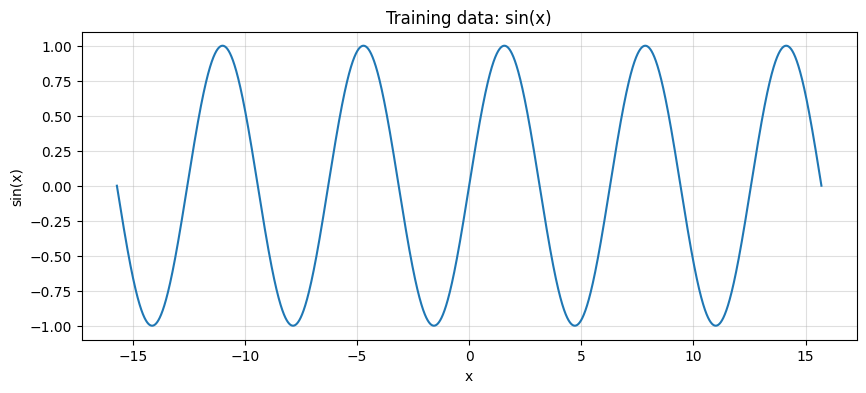

In [38]:
plt.figure(figsize=(10, 4))
plt.plot(x, y)
plt.xlabel("x")
plt.ylabel("sin(x)")
plt.title("Training data: sin(x)")
plt.grid(alpha=0.4)
plt.show()

Time to build our fully connected network

In [109]:
class sinNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.Model = nn.Sequential(
            nn.Linear(1, 1024),
            nn.ReLU(),

            nn.Linear(1024, 512),
            nn.ReLU(),

            nn.Linear(512, 256),
            nn.ReLU(),

            nn.Linear(256, 128),
            nn.ReLU(),

            nn.Linear(128, 1),
        )
    
    def forward(self, x):
        return self.Model(x)


In [114]:
model = sinNet()

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer= optimizer,
    mode = 'min',
    factor= 0.5,
    patience= 10
)

model = model.to(device)
x_tensor = x_tensor.to(device)
y_tensor = y_tensor.to(device)

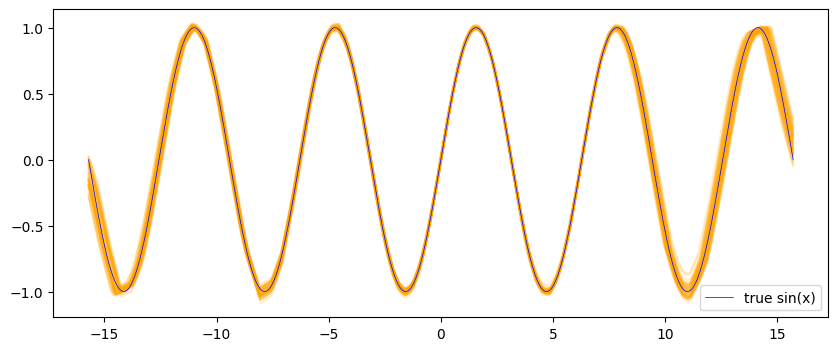

In [115]:
EPOCH = 4000
checkpoint_preds = []


for epoch in range(1, EPOCH+1):
    pred_x = model(x_tensor)

    loss = criterion(pred_x, y_tensor)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    current_lr = optimizer.param_groups[0]['lr']

    if current_lr < 0.0000001:
        # kick it back up
        optimizer.param_groups[0]['lr'] = 0.001

    print(f'epoch: {epoch}, loss = {loss.item()}')

    if epoch % 5 == 0:
        clear_output(wait=True)
        with torch.no_grad():
            y_pred = model(x_tensor)

        y_np = y_pred.cpu().numpy()

        checkpoint_preds.append([x, y_np])

        plt.figure(figsize=(10,4))

        for i, (x, y_p) in enumerate(checkpoint_preds[-50:]):
            alpha_val = (len(checkpoint_preds) - i) / (len(checkpoint_preds)*5)
            plt.plot(x, y_p, alpha=alpha_val, color="orange")
        
        plt.plot(x, y, label="true sin(x)", color="blue", linewidth=0.5)

        plt.legend()
        plt.show()
